# 🔵 MODULE 4 : Clustering — Analyse Non-Supervisée

> **Objectif** : Ignorer les étiquettes (`Categorie`) et découvrir des groupes naturels dans les données.  
> **Méthodes** : K-Means + Elbow Method + Silhouette Score + Visualisation PCA 2D

## 4.1 — Préparation des Données (non-supervisé)

In [51]:
# On ignore les labels — toutes les features numériques uniquement
features_cluster = num_cols  # ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente']

X_cluster = df_clean[features_cluster].copy()

# Standardisation obligatoire pour K-Means
scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_cluster)

print(f"Matrice pour clustering : {X_clust_scaled.shape}")
print(f"Features utilisées : {features_cluster}")
print("\nLabels IGNORÉS (analyse purement non-supervisée).")

Matrice pour clustering : (9620, 6)
Features utilisées : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente']

Labels IGNORÉS (analyse purement non-supervisée).


## 4.2 — Méthode du Coude (Elbow Method) + Silhouette Score

> L'**Elbow Method** mesure l'inertie intra-cluster (WCSS) en fonction du nombre de clusters K.  
> Le **Silhouette Score** mesure la cohésion et la séparation des clusters (de -1 à +1).

k= 2  →  Inertie =   23191.80  |  Silhouette = 0.5467
k= 3  →  Inertie =    7723.79  |  Silhouette = 0.6880
k= 4  →  Inertie =    4100.91  |  Silhouette = 0.7010
k= 5  →  Inertie =    3467.27  |  Silhouette = 0.6061
k= 6  →  Inertie =    3145.54  |  Silhouette = 0.5381
k= 7  →  Inertie =    2875.74  |  Silhouette = 0.5450
k= 8  →  Inertie =    2676.32  |  Silhouette = 0.5271
k= 9  →  Inertie =    2520.58  |  Silhouette = 0.4163
k=10  →  Inertie =    2313.36  |  Silhouette = 0.4031


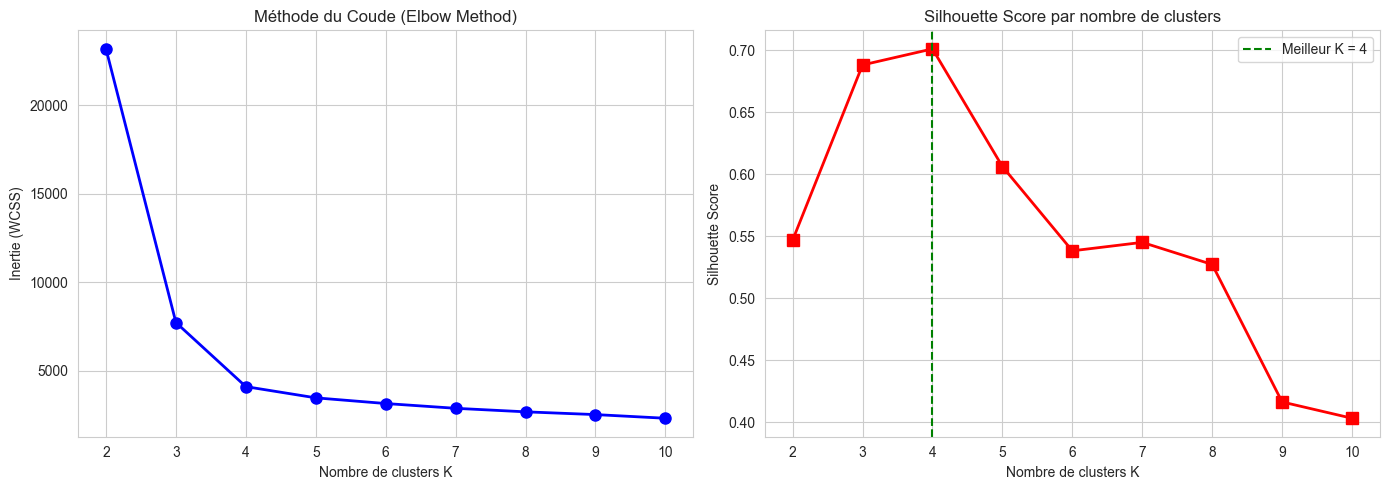


✅ K optimal (Silhouette max) = 4  |  Score = 0.7010


In [ ]:
inertias         = []
silhouette_scores = []
K_range          = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_clust_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_clust_scaled, km.labels_)
    silhouette_scores.append(sil)
    print(f"k={k:2d}  →  Inertie = {km.inertia_:10.2f}  |  Silhouette = {sil:.4f}")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie (WCSS)')
axes[0].set_title('Méthode du Coude (Elbow Method)')
axes[0].grid(True)

# Silhouette curve
axes[1].plot(list(K_range), silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score par nombre de clusters')
axes[1].grid(True)

# Marquer le meilleur K
best_k_sil = list(K_range)[np.argmax(silhouette_scores)]
axes[1].axvline(best_k_sil, color='green', linestyle='--',
                label=f'Meilleur K = {best_k_sil}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n K optimal (Silhouette max) = {best_k_sil}  |  Score = {max(silhouette_scores):.4f}")

## 4.3 — Entraînement K-Means avec K Optimal

In [53]:
OPTIMAL_K = best_k_sil  # peut être surchargé manuellement si nécessaire

kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=20,
    random_state=42
)
kmeans_final.fit(X_clust_scaled)
cluster_labels = kmeans_final.labels_

print(f"K-Means entraîné avec K = {OPTIMAL_K}")
print(f"Inertie finale  : {kmeans_final.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_clust_scaled, cluster_labels):.4f}")

# Distribution des clusters
cluster_dist = pd.Series(cluster_labels).value_counts().sort_index()
print(f"\nDistribution des clusters :")
print(cluster_dist)

K-Means entraîné avec K = 4
Inertie finale  : 4100.91
Silhouette Score: 0.7010

Distribution des clusters :
0    2223
1    2474
2    2268
3    2655
Name: count, dtype: int64


## 4.4 — Réduction de Dimension PCA et Visualisation 2D des Clusters

Variance expliquée — PC1 : 62.9%  |  PC2 : 28.5%
Variance totale expliquée : 91.4%


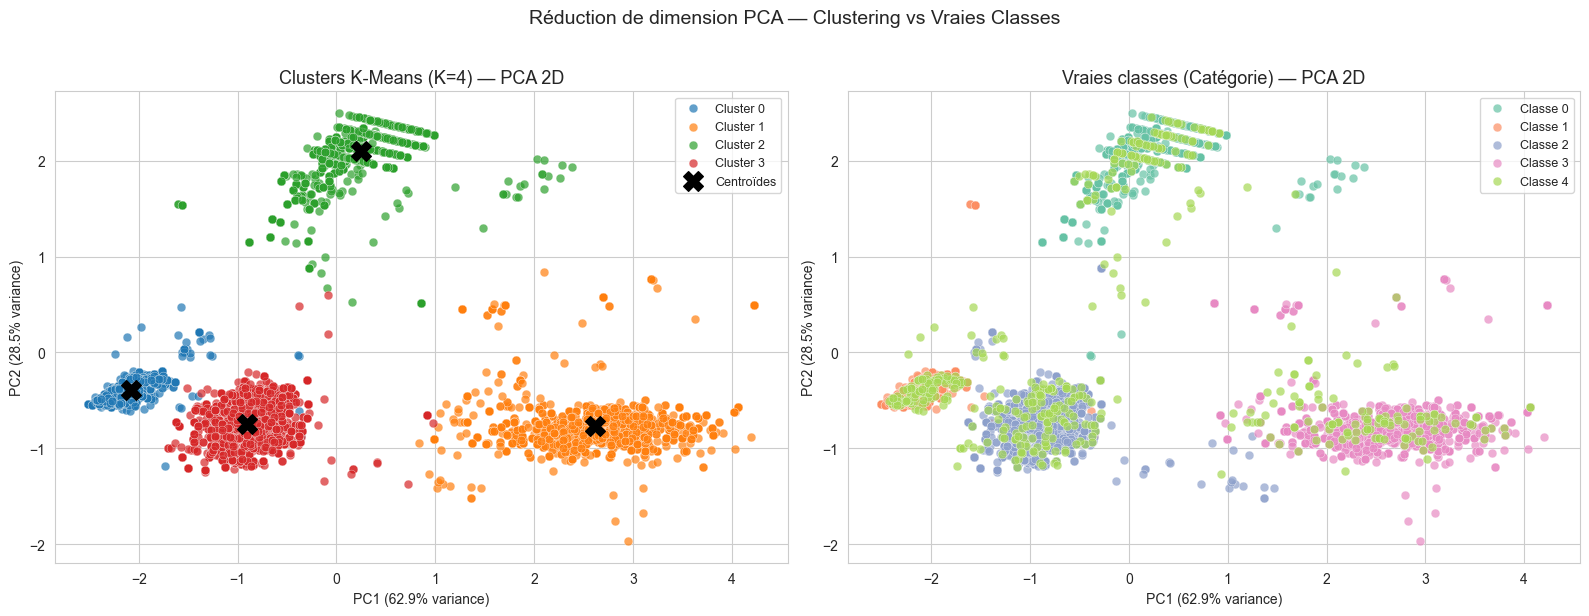

In [54]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)

var_exp = pca.explained_variance_ratio_
print(f"Variance expliquée — PC1 : {var_exp[0]*100:.1f}%  |  PC2 : {var_exp[1]*100:.1f}%")
print(f"Variance totale expliquée : {sum(var_exp)*100:.1f}%")

# DataFrame pour visualisation
pca_df = pd.DataFrame({
    'PC1'    : X_pca[:, 0],
    'PC2'    : X_pca[:, 1],
    'Cluster': cluster_labels,
    'Vrai_Label': df_clean['Categorie'].values  # comparaison visuelle (non utilisé pour le clustering)
})

# ── Figure principale : Clusters K-Means ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 : Clusters K-Means
palette_clusters = sns.color_palette('tab10', OPTIMAL_K)
for k in range(OPTIMAL_K):
    mask = pca_df['Cluster'] == k
    axes[0].scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=[palette_clusters[k]],
        label=f'Cluster {k}',
        alpha=0.7,
        s=40,
        edgecolors='white',
        linewidths=0.3
    )

# Centroïdes
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
axes[0].scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='X', s=200, c='black', zorder=5, label='Centroïdes'
)
axes[0].set_title(f'Clusters K-Means (K={OPTIMAL_K}) — PCA 2D', fontsize=13)
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)')
axes[0].legend(loc='best', fontsize=9)

# Plot 2 : Vraies étiquettes (pour comparaison)
n_classes = pca_df['Vrai_Label'].nunique()
palette_labels = sns.color_palette('Set2', n_classes)
for c, color in zip(sorted(pca_df['Vrai_Label'].unique()), palette_labels):
    mask = pca_df['Vrai_Label'] == c
    axes[1].scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=[color],
        label=f'Classe {c}',
        alpha=0.7,
        s=40,
        edgecolors='white',
        linewidths=0.3
    )
axes[1].set_title('Vraies classes (Catégorie) — PCA 2D', fontsize=13)
axes[1].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)')
axes[1].legend(loc='best', fontsize=9)

plt.suptitle('Réduction de dimension PCA — Clustering vs Vraies Classes', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4.5 — Profil des Clusters (Analyse des Centroïdes)

Profil des clusters (moyenne ± std) :


Poids         Volume        Conductivite      Opacite        \
           mean    std    mean    std         mean  std    mean   std   
Cluster                                                                 
0         16.33  14.08   34.17  21.35          0.0  0.0    1.00  0.01   
1        179.81  37.97  357.04  65.61          0.0  0.0    0.11  0.11   
2         61.23  25.66  120.72  35.43          0.0  0.0    1.00  0.05   
3         29.76  14.25   59.15  27.88          0.0  0.0    0.40  0.11   

        Rigidite       Prix_Revente        
            mean   std         mean   std  
Cluster                                    
0           2.05  0.87         0.79  0.40  
1           9.05  0.82         5.47  1.35  
2           8.53  1.19        13.85  1.82  
3           4.01  0.87         2.91  0.98

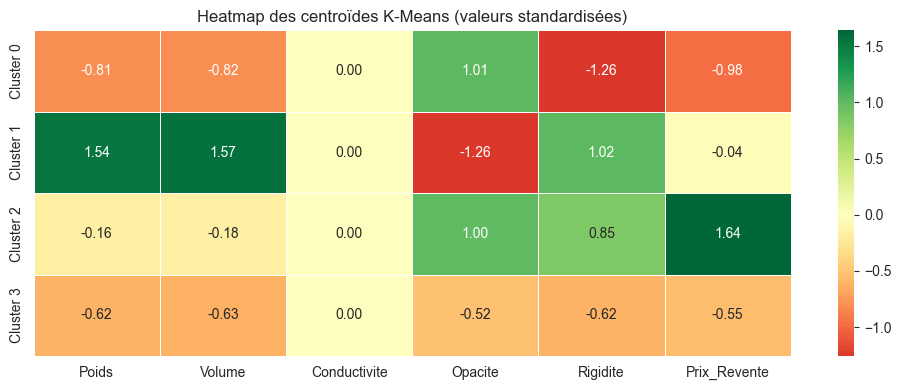

In [55]:
# Ajouter les labels de cluster au dataframe original
X_cluster_labeled = X_cluster.copy()
X_cluster_labeled['Cluster'] = cluster_labels

# Statistiques par cluster
cluster_profile = X_cluster_labeled.groupby('Cluster').agg(['mean', 'std']).round(2)
print("Profil des clusters (moyenne ± std) :")
display(cluster_profile)

# Heatmap des centroïdes normalisés
centroids_df = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=features_cluster,
    index=[f'Cluster {i}' for i in range(OPTIMAL_K)]
)

plt.figure(figsize=(10, 4))
sns.heatmap(
    centroids_df,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    center=0
)
plt.title('Heatmap des centroïdes K-Means (valeurs standardisées)', fontsize=12)
plt.tight_layout()
plt.show()

## 4.6 — Variance Expliquée par PCA (Scree Plot)

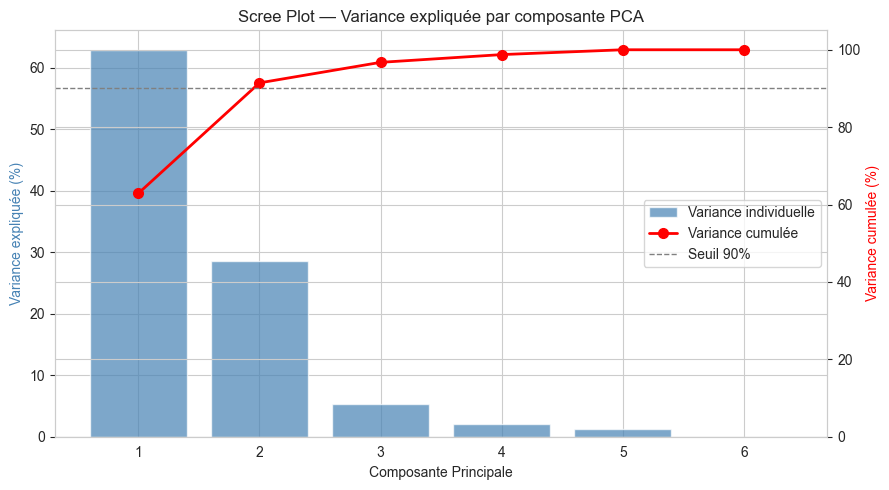

Composantes nécessaires pour 80% de variance : 2
Composantes nécessaires pour 90% de variance : 2
Composantes nécessaires pour 95% de variance : 3


In [56]:
pca_full = PCA(random_state=42)
pca_full.fit(X_clust_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
indvar = pca_full.explained_variance_ratio_ * 100

fig, ax1 = plt.subplots(figsize=(9, 5))

bars = ax1.bar(range(1, len(indvar)+1), indvar,
               color='steelblue', alpha=0.7, label='Variance individuelle')
ax1.set_xlabel('Composante Principale')
ax1.set_ylabel('Variance expliquée (%)', color='steelblue')
ax1.set_xticks(range(1, len(indvar)+1))

ax2 = ax1.twinx()
ax2.plot(range(1, len(cumvar)+1), cumvar, 'ro-',
         linewidth=2, markersize=7, label='Variance cumulée')
ax2.axhline(90, color='gray', linestyle='--', linewidth=1, label='Seuil 90%')
ax2.set_ylabel('Variance cumulée (%)', color='red')
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('Scree Plot — Variance expliquée par composante PCA')
plt.tight_layout()
plt.show()

for threshold in [80, 90, 95]:
    n_comp = (cumvar >= threshold).argmax() + 1
    print(f"Composantes nécessaires pour {threshold}% de variance : {n_comp}")

---
# 📊 Synthèse Générale

In [ ]:
print("=" * 70)
print("  RÉSUMÉ FINAL")
print("=" * 70)

best_clf = results_clf['F1-score'].idxmax()
best_reg = results_reg['R2'].idxmax()

print(f"\n Meilleur modèle de Classification  : {best_clf}")
print(f"   F1-score (Test) = {results_clf.loc[best_clf, 'F1-score']:.3f}")
print(f"   Accuracy (Test) = {results_clf.loc[best_clf, 'Accuracy']:.3f}")

print(f"\n Meilleur modèle de Régression       : {best_reg}")
print(f"   R²   (Test) = {results_reg.loc[best_reg, 'R2']:.4f}")
print(f"   RMSE (Test) = {results_reg.loc[best_reg, 'RMSE']:.4f}")

print(f"\n🔬 Tuning (GridSearchCV sur GBC)")
print(f"   F1 Test = {grid_f1:.4f}  |  Accuracy = {grid_acc:.4f}")
if optuna_f1 is not None:
    print(f"\n🔬 Tuning (Optuna sur GBC)")
    print(f"   F1 Test = {optuna_f1:.4f}  |  Accuracy = {optuna_acc:.4f}")

print(f"\n Clustering K-Means")
print(f"   K optimal (Silhouette) = {OPTIMAL_K}")
print(f"   Silhouette Score       = {silhouette_score(X_clust_scaled, cluster_labels):.4f}")
print(f"   PCA 2D variance totale = {sum(pca.explained_variance_ratio_)*100:.1f}%")

print(f"\nSplit : 70% Train | 15% Val | 15% Test (stratifié sur Catégorie)")
print("=" * 70)

  RÉSUMÉ FINAL

🏆 Meilleur modèle de Classification  : Gradient Boosting
   F1-score (Test) = 0.943
   Accuracy (Test) = 0.956

🏆 Meilleur modèle de Régression       : Random Forest Reg
   R²   (Test) = 0.9797
   RMSE (Test) = 0.7161

🔬 Tuning (GridSearchCV sur GBC)
   F1 Test = 0.9415  |  Accuracy = 0.9550

🔵 Clustering K-Means
   K optimal (Silhouette) = 4
   Silhouette Score       = 0.7010
   PCA 2D variance totale = 91.4%

Split : 70% Train | 15% Val | 15% Test (stratifié sur Catégorie)
